- We have gone through logs and traces. Next is Metrics!
- What are metrics?
- Why are they important?
- CloudWatch Metrics Concepts
- We can send Metrics directly to CloudWatch via the AWS SDK or CLI
- We can also send metrics via logs which cloudwatch can parse and create metrics out of it
  - aws embedded metric format (EMF)
  - demonstrate this using `aws-embedded-metrics` and `aws-lambda-powertools` libraries
- Instrument our code to send custom metrics to CloudWatch using `aws-embedded-metrics`.

- https://docs.aws.amazon.com/code-library/latest/ug/python_3_cloudwatch_code_examples.html
- https://github.com/awsdocs/aws-doc-sdk-examples/tree/main/python/example_code/cloudwatch

1. Cloudwatch Concepts
2. Using `boto3`
    - Create some dummy datapoints
    - Push them to CloudWatch
    - Now manually do metric aggregation and show the same using boto3
3. Using `aws-embedded-metrics`
4. Using `aws-lambda-powertools`

# Metrics on CloudWatch

In [21]:
# !localstack start --detached

In [7]:
import os
from rich import print
import matplotlib.pyplot as plt

## Using `boto3`

In [2]:
# os.environ["AWS_PROFILE"] = "localstack"
os.environ["AWS_PROFILE"] = "cloud-course"

# AWS CloudWatch Namespace for the metrics
NAMESPACE = "API/Metrics"

# Metric Name
METRIC_NAME = "ResponseLatency"

# Unit of the Metric
UNIT = "Milliseconds"

# Number of Data Points to Generate
NUM_POINTS = 1000

# Hours Before the Current Time
HOURS = 0.25  # 15 minutes

In [3]:
from utils import generate_random_metrics_df


metrics_data_df = generate_random_metrics_df(
    namespace=NAMESPACE,
    metric_name=METRIC_NAME,
    unit=UNIT,
    num_points=NUM_POINTS,
    hours=HOURS,
    publish=False,
)

# metrics_data_df.to_csv("metrics_data.csv", index=False)
metrics_data_df.head()

,MetricName,Value,Unit,Dimensions,Timestamp
0,ResponseLatency,1298.867432,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:49.024795+00:00
1,ResponseLatency,164.601864,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:49.298446+00:00
2,ResponseLatency,1260.803966,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:49.974716+00:00
3,ResponseLatency,136.256689,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:50.051186+00:00
4,ResponseLatency,230.607513,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:51.132247+00:00


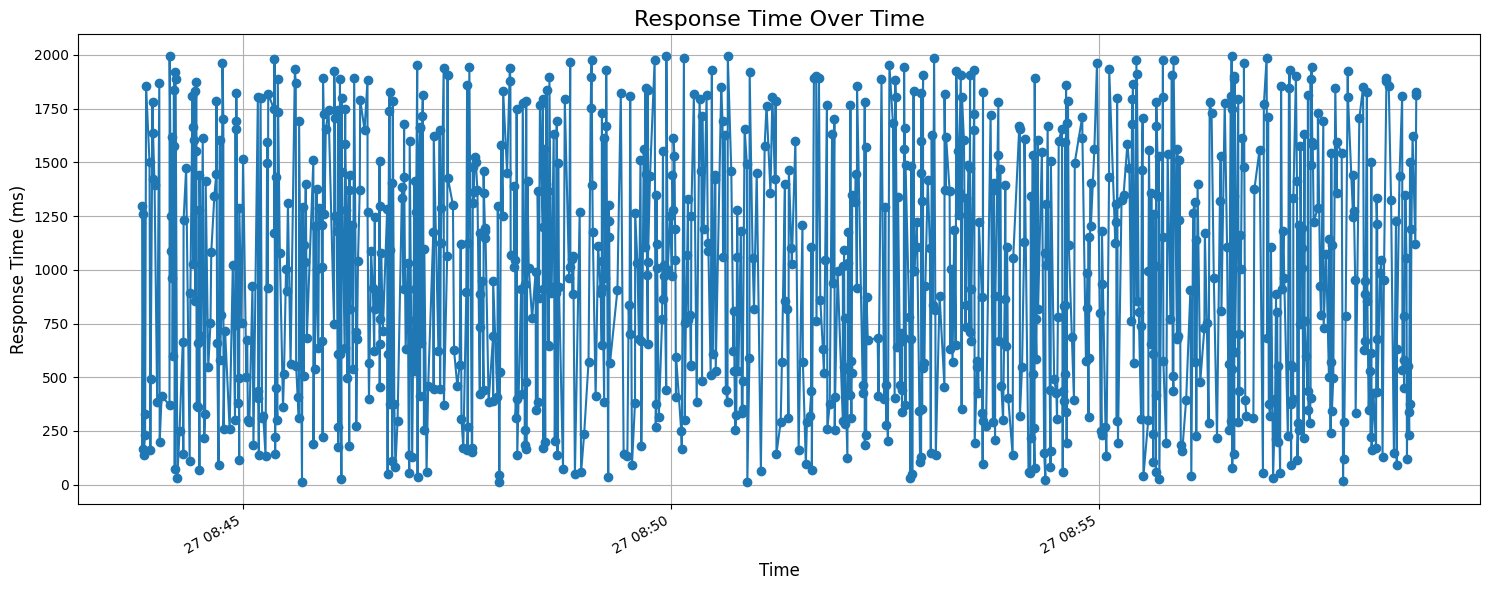

In [18]:
import matplotlib.pyplot as plt


# Pivot the data to prepare for plotting
pivot_df = metrics_data_df.pivot(index="Timestamp", columns="MetricName", values="Value")

# Plot the data
plt.figure(figsize=(15, 6))
pivot_df.plot(ax=plt.gca(), marker="o", linestyle="-")

plt.title("Response Time Over Time", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("Response Time (ms)", fontsize=12)
plt.legend().remove()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
labeled_metrics_data_df = metrics_data_df.copy()

# Create a Label column based on dimensions
labeled_metrics_data_df["Label"] = labeled_metrics_data_df["Dimensions"].apply(
    lambda x: f"{x[1]['Value']} {x[2]['Value']}"
)

labeled_metrics_data_df.head()

,MetricName,Value,Unit,Dimensions,Timestamp,Label
0,ResponseLatency,1298.867432,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:49.024795+00:00,POST 200
1,ResponseLatency,164.601864,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:49.298446+00:00,GET 200
2,ResponseLatency,1260.803966,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:49.974716+00:00,POST 200
3,ResponseLatency,136.256689,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:50.051186+00:00,POST 200
4,ResponseLatency,230.607513,Milliseconds,"[{'Name': 'Endpoint', 'Value': '/api/v1/files'...",2024-12-27 08:43:51.132247+00:00,GET 201


In [141]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Get the unique labels
# unique_labels = labeled_metrics_data_df["Label"].unique()

# # Create a figure with subplots, one for each label
# fig, axes = plt.subplots(len(unique_labels), 1, figsize=(15, 4 * len(unique_labels)), sharex=True)

# # Ensure axes is iterable in case there is only one subplot
# if len(unique_labels) == 1:
#     axes = [axes]

# # Generate a colormap using the new recommended method
# colormap = plt.colormaps["twilight"]

# # Randomly choose unique colors from the colormap
# color_indices = np.random.choice(range(len(colormap.colors)), size=len(unique_labels), replace=False)
# random_colors = [colormap.colors[idx] for idx in color_indices]
# # print(random_colors)

# # Plot each label in its respective subplot
# for ax, label, color in zip(axes, unique_labels, random_colors):
#     label_df = labeled_metrics_data_df[labeled_metrics_data_df["Label"] == label]
#     label_df = label_df.pivot(index="Timestamp", columns="MetricName", values="Value")

#     # Use the randomly chosen color
#     label_df.plot(ax=ax, marker="o", linestyle="-", color=color)

#     ax.set_title(f"Response Time Over Time for {label}", fontsize=14)
#     ax.set_xlabel("Time", fontsize=12)
#     ax.set_ylabel("Response Time (ms)", fontsize=12)
#     ax.legend().remove()
#     ax.grid(True)

# # Adjust layout to prevent overlap
# plt.tight_layout()
# plt.savefig("response_time_over_time_new.png", format="png", dpi=500)
# plt.show()

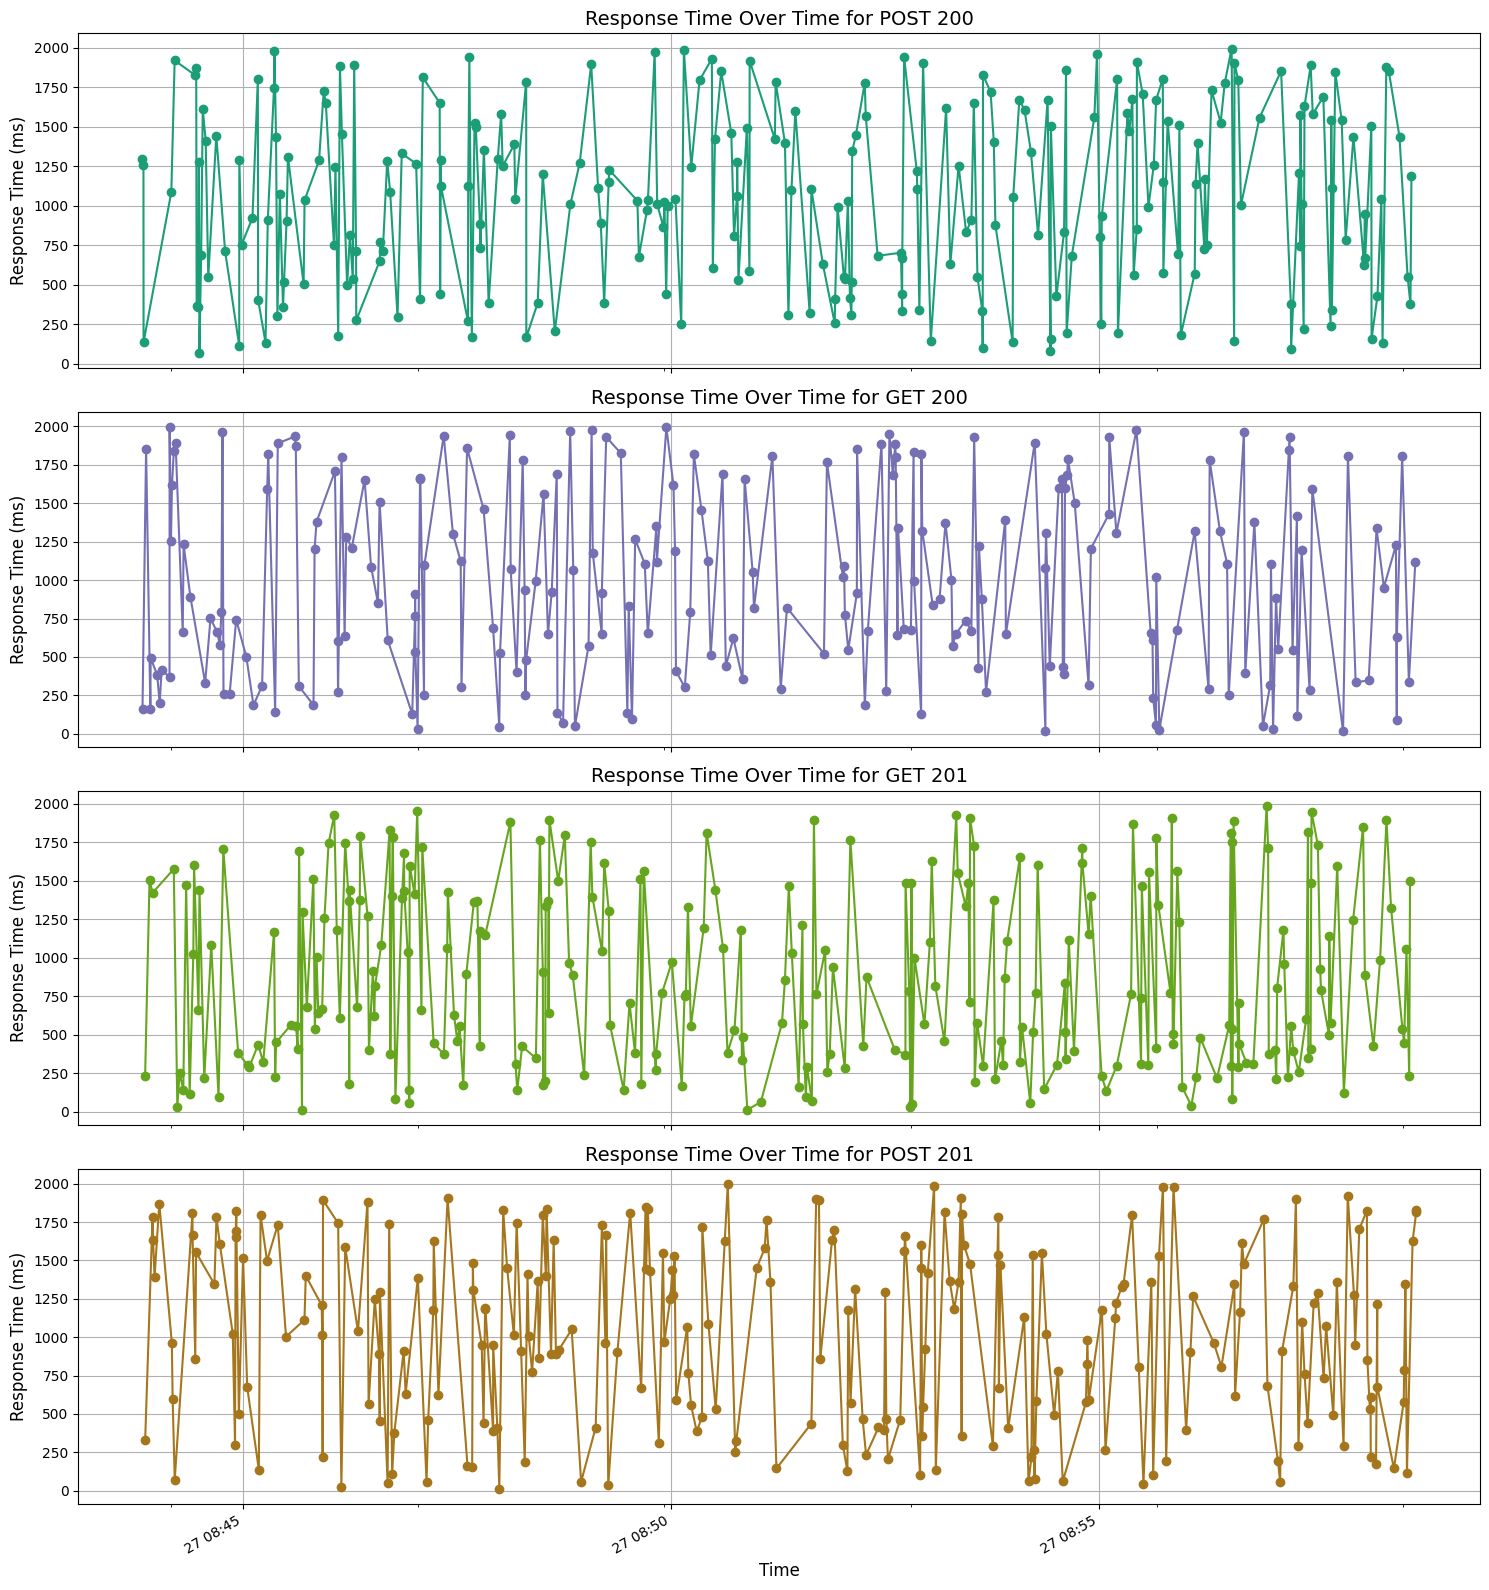

In [123]:
import matplotlib.pyplot as plt

# Get the unique labels
unique_labels = labeled_metrics_data_df["Label"].unique()

# Create a figure with subplots, one for each label
fig, axes = plt.subplots(len(unique_labels), 1, figsize=(15, 4 * len(unique_labels)), sharex=True)

# Ensure axes is iterable in case there is only one subplot
if len(unique_labels) == 1:
    axes = [axes]

# Generate a colormap using the new recommended method
colormap = plt.colormaps["Dark2"]

# Plot each label in its respective subplot
for ax, label, color_index in zip(axes, unique_labels, range(len(unique_labels))):
    label_df = labeled_metrics_data_df[labeled_metrics_data_df["Label"] == label]
    label_df = label_df.pivot(index="Timestamp", columns="MetricName", values="Value")

    # Use colormap to assign unique colors
    label_df.plot(ax=ax, marker="o", linestyle="-", color=colormap(color_index / len(unique_labels)))

    ax.set_title(f"Response Time Over Time for {label}", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Response Time (ms)", fontsize=12)
    ax.legend().remove()
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

In [138]:
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import numpy as np

# # Get the unique labels
# unique_labels = labeled_metrics_data_df["Label"].unique()

# # Create a figure with subplots, one for each label
# fig, axes = plt.subplots(len(unique_labels), 1, figsize=(15, 4 * len(unique_labels)), sharex=True)

# # Ensure axes is iterable in case there is only one subplot
# if len(unique_labels) == 1:
#     axes = [axes]

# # Generate a colormap
# colormap = cm.get_cmap("Set2", len(unique_labels))

# # Plot each label in its respective subplot
# for ax, label, color_index in zip(axes, unique_labels, range(len(unique_labels))):
#     label_df = labeled_metrics_data_df[labeled_metrics_data_df["Label"] == label]
#     label_df = label_df.pivot(index="Timestamp", columns="MetricName", values="Value")

#     label_df.plot(ax=ax, marker="o", linestyle="-", color=colormap(color_index))

#     ax.set_title(f"Response Time Over Time for {label}", fontsize=14)
#     ax.set_xlabel("Time", fontsize=12)
#     ax.set_ylabel("Response Time (ms)", fontsize=12)
#     ax.legend().remove()
#     ax.grid(True)

# # Adjust layout to prevent overlap
# plt.tight_layout()
# plt.show()


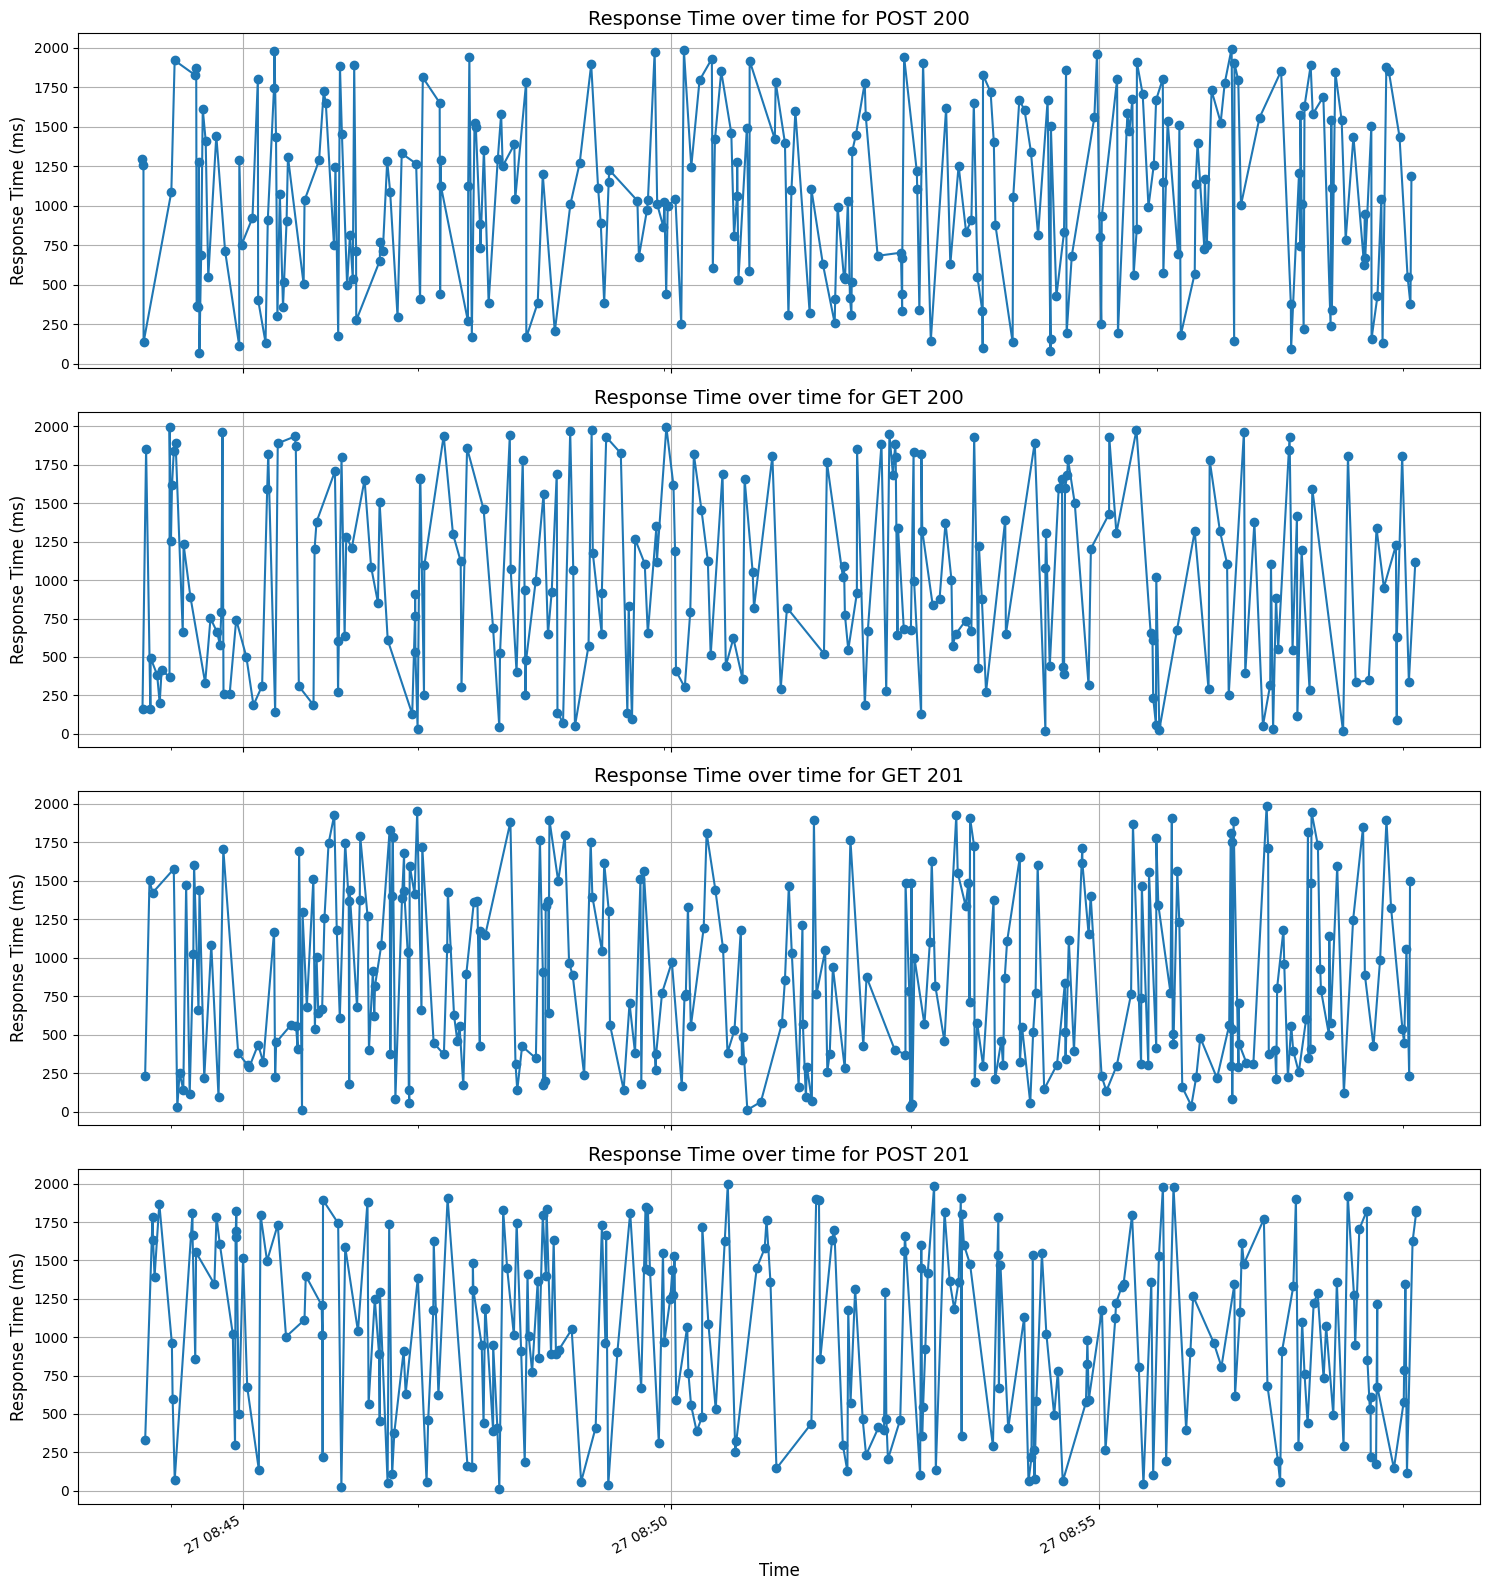

In [17]:
# Get the unique labels
unique_labels = labeled_metrics_data_df["Label"].unique()

# Create a figure with subplots, one for each label
fig, axes = plt.subplots(len(unique_labels), 1, figsize=(15, 4 * len(unique_labels)), sharex=True)

# Ensure axes is iterable in case there is only one subplot
if len(unique_labels) == 1:
    axes = [axes]

# Plot each label in its respective subplot
for ax, label in zip(axes, unique_labels):
    label_df = labeled_metrics_data_df[labeled_metrics_data_df["Label"] == label]
    label_df = label_df.pivot(index="Timestamp", columns="MetricName", values="Value")

    label_df.plot(ax=ax, marker="o", linestyle="-")

    ax.set_title(f"Response Time over time for {label}", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Response Time (ms)", fontsize=12)
    ax.legend().remove()
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
# plt.savefig("response_time_over_time.png", format="png", dpi=500)
plt.show()

In [140]:
# for label in labeled_metrics_data_df["Label"].unique():
#     label_df = labeled_metrics_data_df[labeled_metrics_data_df["Label"] == label]
#     label_df = label_df.pivot(index="Timestamp", columns="MetricName", values="Value")

#     plt.figure(figsize=(15, 6))
#     label_df.plot(ax=plt.gca(), marker="o", linestyle="-")

#     plt.title(f"Response Time Over Time for {label}", fontsize=16)
#     plt.xlabel("Time", fontsize=12)
#     plt.ylabel("Response Time (ms)", fontsize=12)
#     plt.legend().remove()
#     plt.grid(True)
#     plt.tight_layout()
#     plt.show()

In [185]:
labeled_metrics_data_df = metrics_data_df.copy()

# Create a Label column based on dimensions
labeled_metrics_data_df["Label"] = labeled_metrics_data_df["Dimensions"].apply(
    lambda x: f"{x[1]['Value']} {x[2]['Value']}"
)

# Set Timestamp as the index for resampling
labeled_metrics_data_df = labeled_metrics_data_df.set_index("Timestamp")

# Group by Label and resample by 5-minute intervals
metrics_data_agg = (
    labeled_metrics_data_df.groupby("Label")  # Group by the label first
    .resample("5min")  # Resample each group by 5-minute intervals
    .agg(
        SampleCount=("Value", "count"),
        Average=("Value", "mean"),
        Sum=("Value", "sum"),
        Minimum=("Value", "min"),
        Maximum=("Value", "max"),
        P95=("Value", lambda x: x.quantile(0.95)),
    )
    .reset_index()  # Reset index to make Label and Timestamp regular columns
)

metrics_data_agg.head()

,Label,Timestamp,SampleCount,Average,Sum,Minimum,Maximum,P95
0,GET 200,2024-12-27 08:40:00+00:00,25,869.778766,21744.469155,160.338541,1993.314825,1947.328256
1,GET 200,2024-12-27 08:45:00+00:00,76,1004.940953,76375.512396,33.929998,1994.501803,1938.918926
2,GET 200,2024-12-27 08:50:00+00:00,74,1046.299865,77426.189991,20.593636,1952.123688,1884.781339
3,GET 200,2024-12-27 08:55:00+00:00,46,904.389810,41601.931266,15.822061,1976.931940,1932.541878
4,GET 201,2024-12-27 08:40:00+00:00,18,830.013526,14940.243464,30.022882,1703.192908,1618.062175


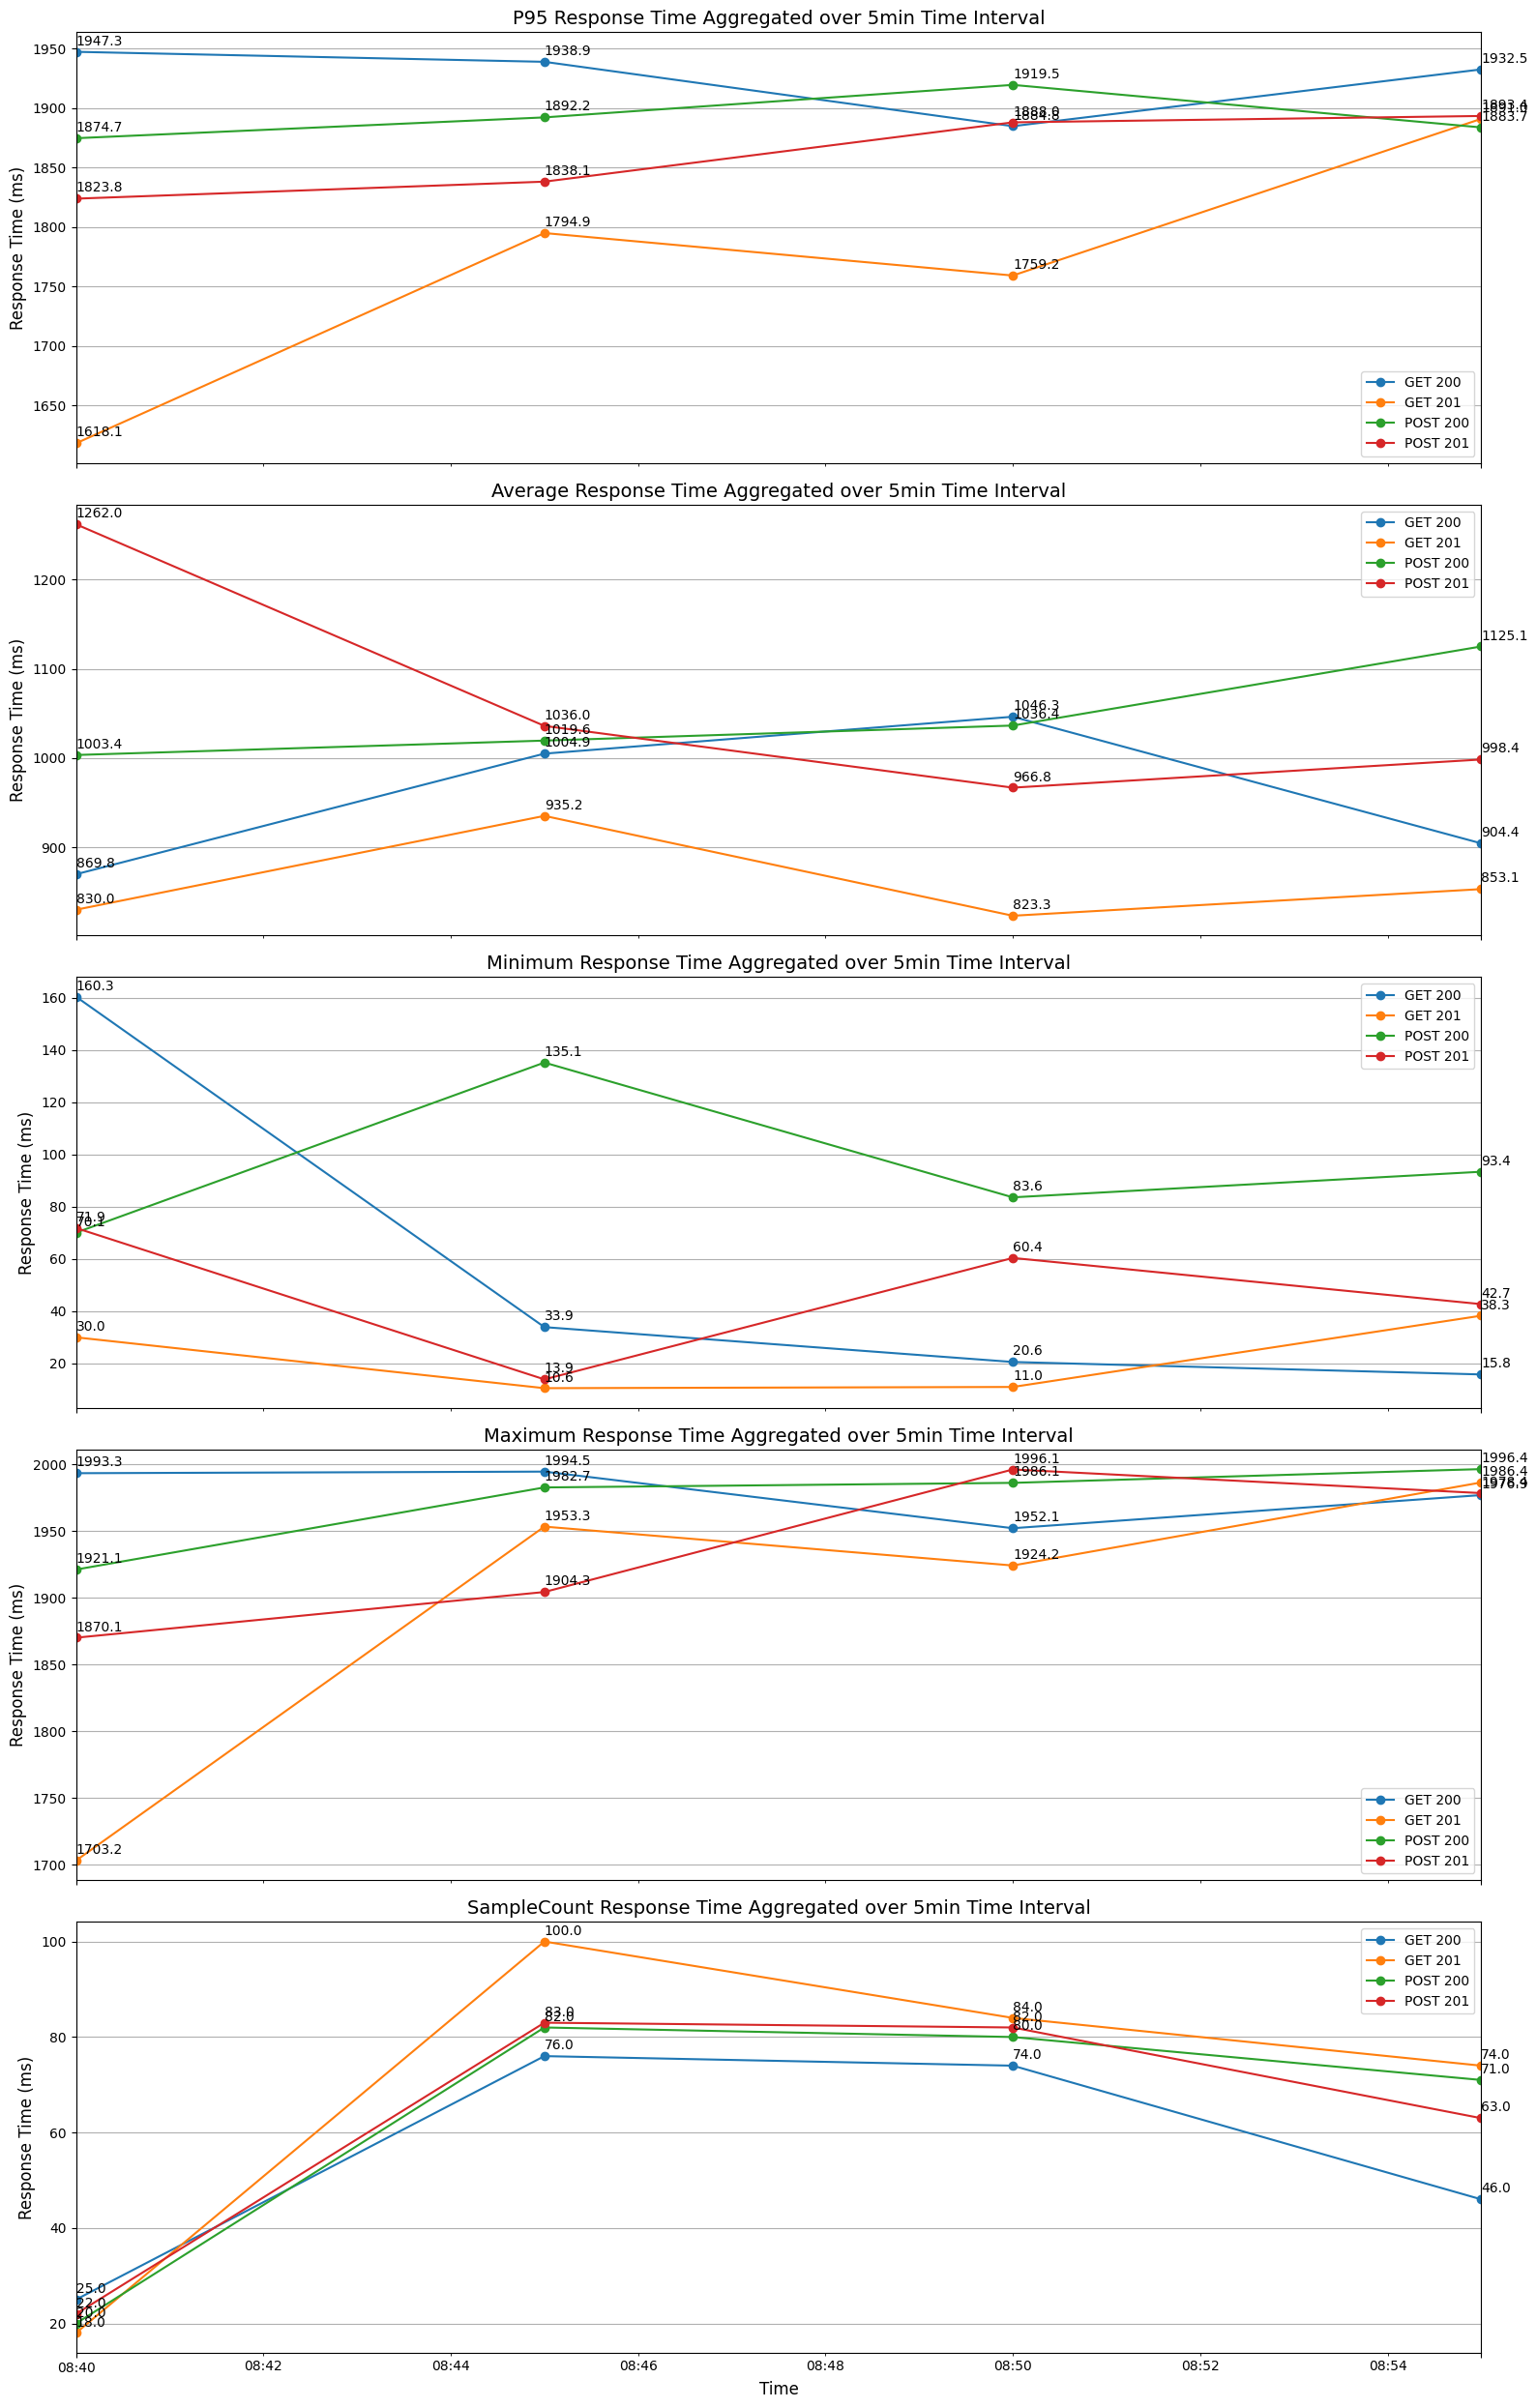

In [211]:
import matplotlib.pyplot as plt

# Get the unique labels
unique_metrics = ["P95", "Average", "Minimum", "Maximum", "SampleCount"]

# Create a figure with subplots, one for each metric
fig, axes = plt.subplots(len(unique_metrics), 1, figsize=(16, 5 * len(unique_metrics)), sharex=True)

# Ensure axes is iterable in case there is only one subplot
if len(unique_metrics) == 1:
    axes = [axes]

# Generate a colormap using the new recommended method
colormap = plt.colormaps["Dark2"]

# Plot each metric in its respective subplot
for ax, metric, color_index in zip(axes, unique_metrics, range(len(unique_metrics))):
    metric_df = metrics_data_agg.pivot(index="Timestamp", columns="Label", values=metric)

    # Use colormap to assign unique colors
    metric_df.plot(ax=ax, marker="o", linestyle="-")

    # Annotate values
    for col in metric_df.columns:
        for x, y in zip(metric_df.index, metric_df[col]):
            ax.annotate(f"{y:.1f}",  # Format the value to 2 decimal places
                        (x, y),     # Position of the annotation
                        textcoords="offset points",  # Offset to avoid overlap
                        xytext=(0, 5),  # Vertical offset
                        ha="left",   # Horizontal alignment
                        fontsize=10)    # Font size for annotations

    ax.set_title(f"{metric} Response Time Aggregated over 5min Time Interval", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Response Time (ms)", fontsize=12)
    ax.legend()
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig("response_time_aggregated.png", format="png", dpi=500)
plt.show()

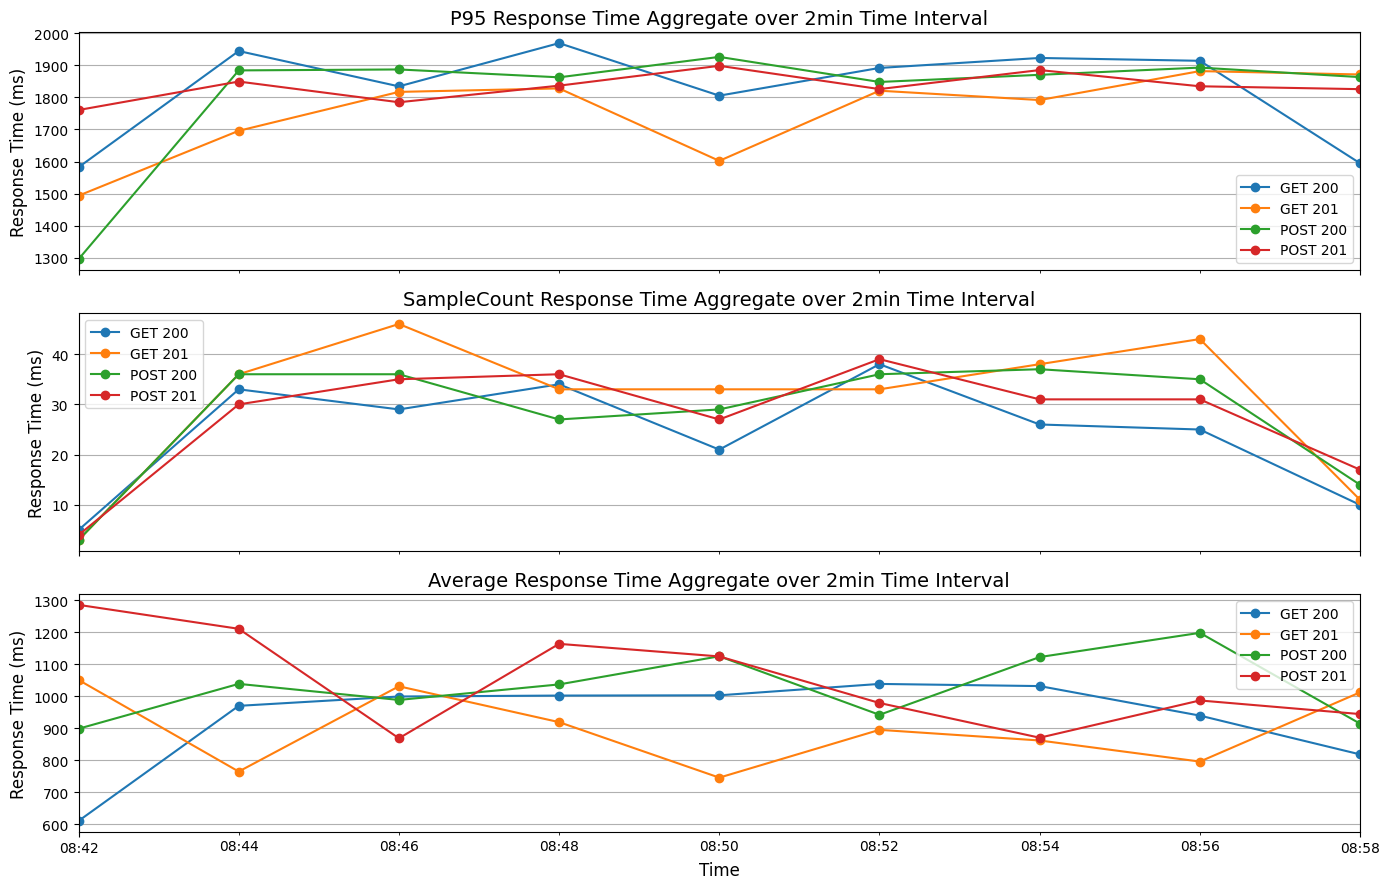

In [157]:
import matplotlib.pyplot as plt

# Get the unique labels
unique_metrics = ["P95", "SampleCount", "Average"]

# Create a figure with subplots, one for each label
fig, axes = plt.subplots(len(unique_metrics), 1, figsize=(14, 3 * len(unique_metrics)), sharex=True)

# Ensure axes is iterable in case there is only one subplot
if len(unique_metrics) == 1:
    axes = [axes]

# Generate a colormap using the new recommended method
colormap = plt.colormaps["Dark2"]

# Plot each label in its respective subplot
for ax, metric, color_index in zip(axes, unique_metrics, range(len(unique_metrics))):
    metric_df = metrics_data_agg.pivot(index="Timestamp", columns="Label", values=metric)

    # Use colormap to assign unique colors
    metric_df.plot(ax=ax, marker="o", linestyle="-")

    ax.set_title(f"{metric} Response Time Aggregate over 2min Time Interval", fontsize=14)
    ax.set_xlabel("Time", fontsize=12)
    ax.set_ylabel("Response Time (ms)", fontsize=12)
    ax.legend()
    ax.grid(True)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

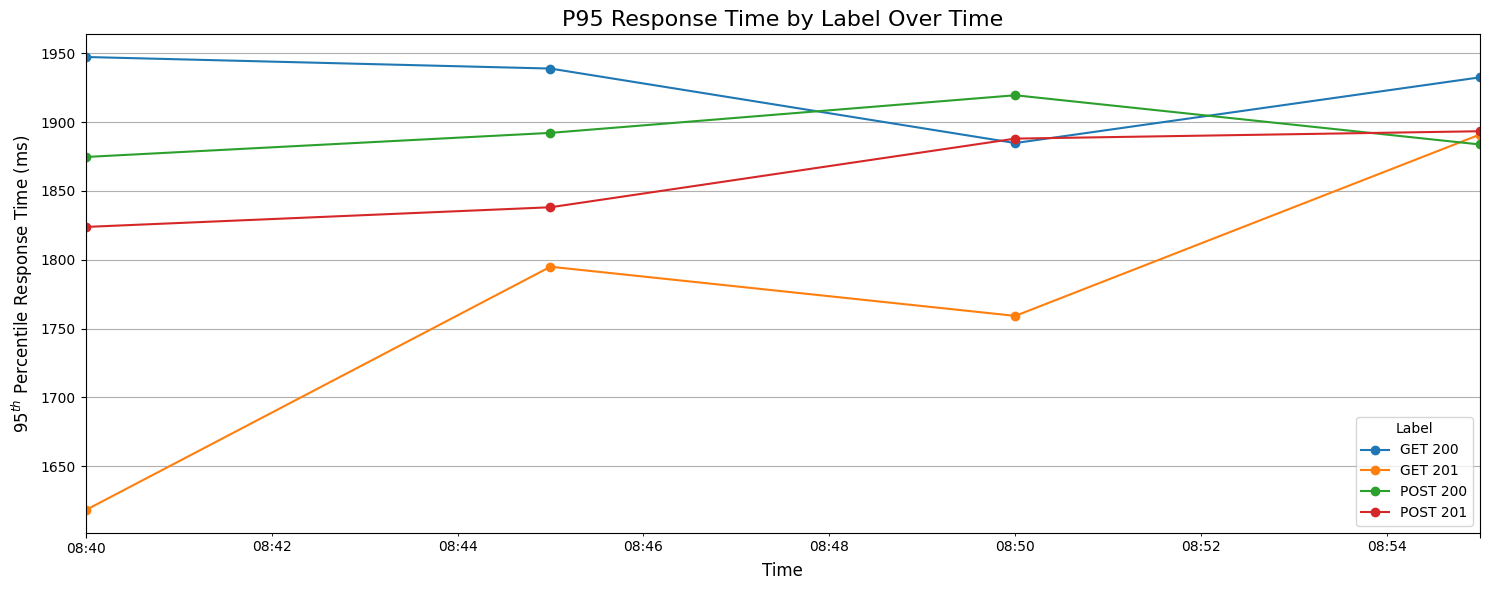

In [143]:
from utils import plot_line_graph, plot_stacked_area_graph

# Plot the line graph
plot_line_graph(metrics_data_agg)

# Plot the stacked area graph
# plot_stacked_area_graph(metrics_data_agg)

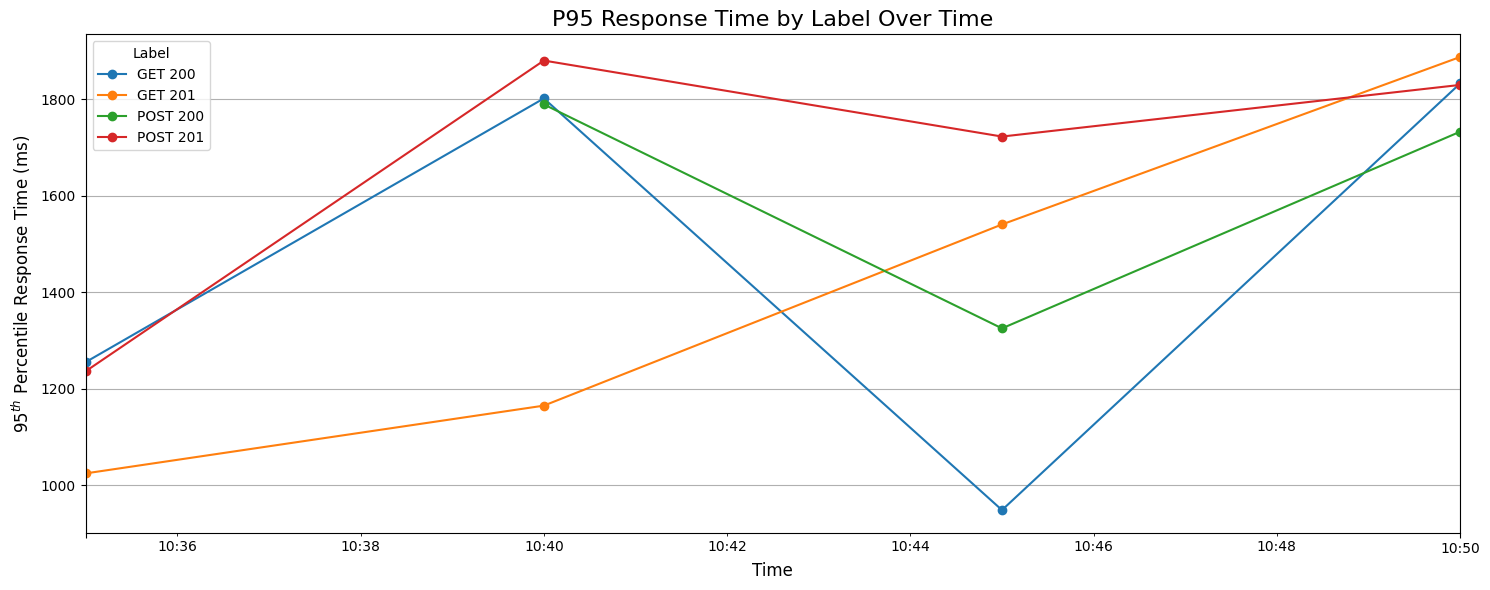

In [82]:
# Pivot the data to prepare for plotting
pivot_df1 = metrics_data_agg.pivot(index="Timestamp", columns="Label", values="P95")

# Plot the data
plt.figure(figsize=(15, 6))
pivot_df1.plot(ax=plt.gca(), marker="o", linestyle="-")

plt.title("P95 Response Time by Label Over Time", fontsize=16)
plt.xlabel("Time", fontsize=12)
plt.ylabel("95$^{th}$ Percentile Response Time (ms)", fontsize=12)
plt.legend(title="Label")
plt.grid(True)
plt.tight_layout()
plt.show()

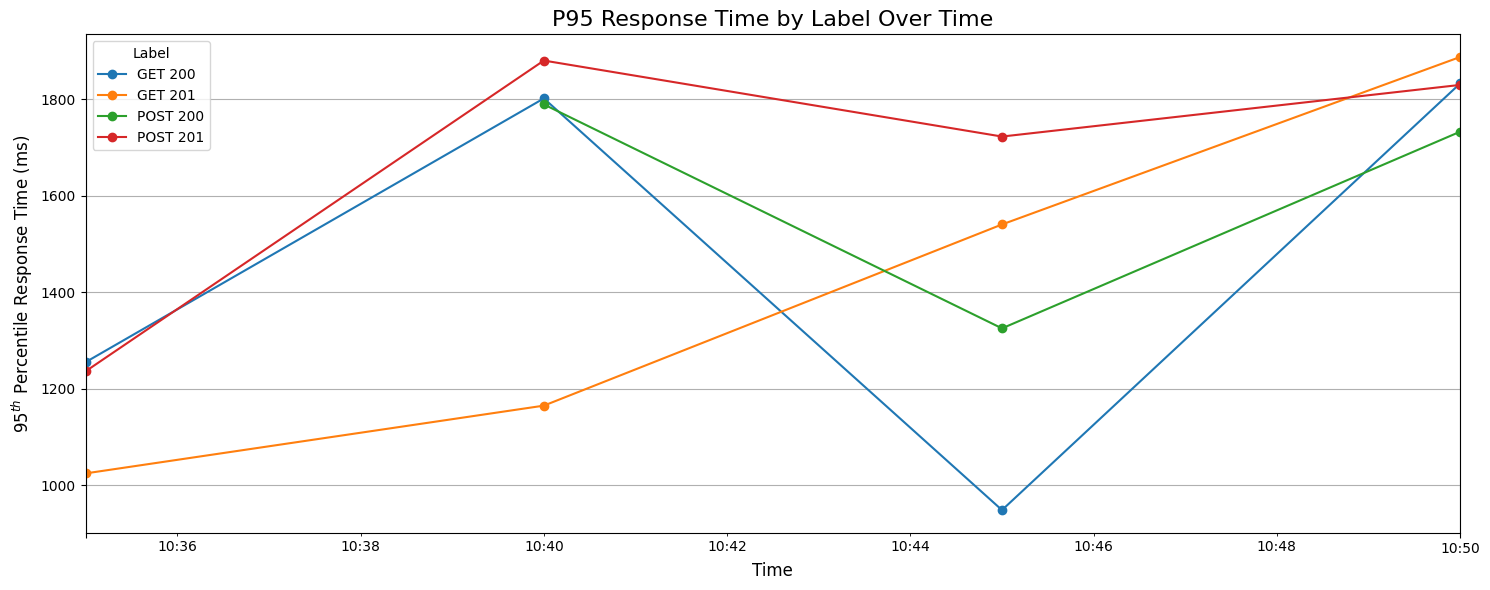

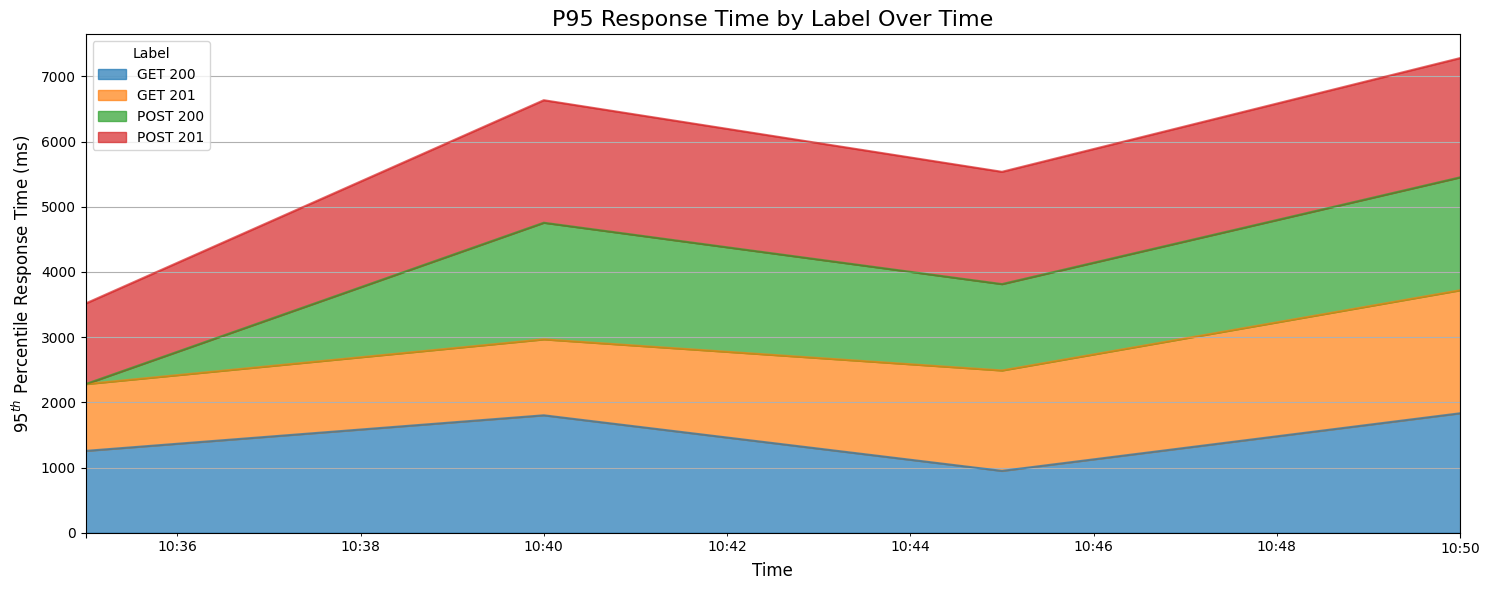

In [78]:
from utils import plot_line_graph, plot_stacked_area_graph

# Plot the line graph
plot_line_graph(metrics_data_agg)

# Plot the stacked area graph
plot_stacked_area_graph(metrics_data_agg)

In [32]:
import boto3
from datetime import timedelta, datetime, timezone


END_TIME = datetime.now(timezone.utc)
START_TIME = END_TIME - timedelta(hours=2)


# Statistics to retrieve
STATISTICS = ["SampleCount", "Sum", "Average", "Minimum", "Maximum"]
EXTENDED_STATISTICS = ["p95"]

cw_client = boto3.client("cloudwatch")


response = cw_client.get_metric_statistics(
    Namespace=NAMESPACE,
    MetricName=METRIC_NAME,
    StartTime=START_TIME,
    EndTime=END_TIME,
    Period=300,  # Metric data is aggregated by 5-minute intervals (60 seconds * 5 minutes)
    Statistics=STATISTICS,
    ExtendedStatistics=EXTENDED_STATISTICS,
    Unit=UNIT,
)

print(response)

{
    'Label': 'ResponseLatency',
    'Datapoints': [],
    'ResponseMetadata': {
        'RequestId': '29c01eff-91c1-45b5-9ddf-446a3a765b05',
        'HTTPStatusCode': 200,
        'HTTPHeaders': {
            'x-amzn-requestid': '29c01eff-91c1-45b5-9ddf-446a3a765b05',
            'content-type': 'text/xml',
            'content-length': '338',
            'date': 'Tue, 17 Dec 2024 16:09:39 GMT'
        },
        'RetryAttempts': 0
    }
}

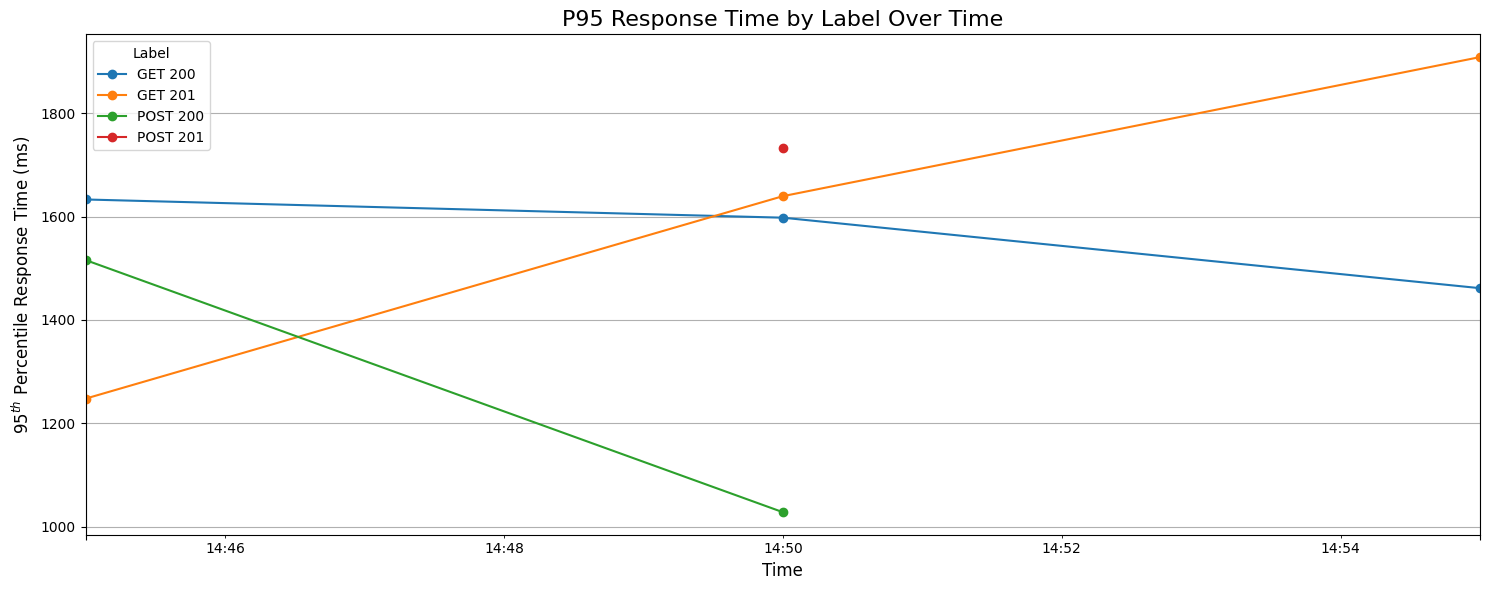

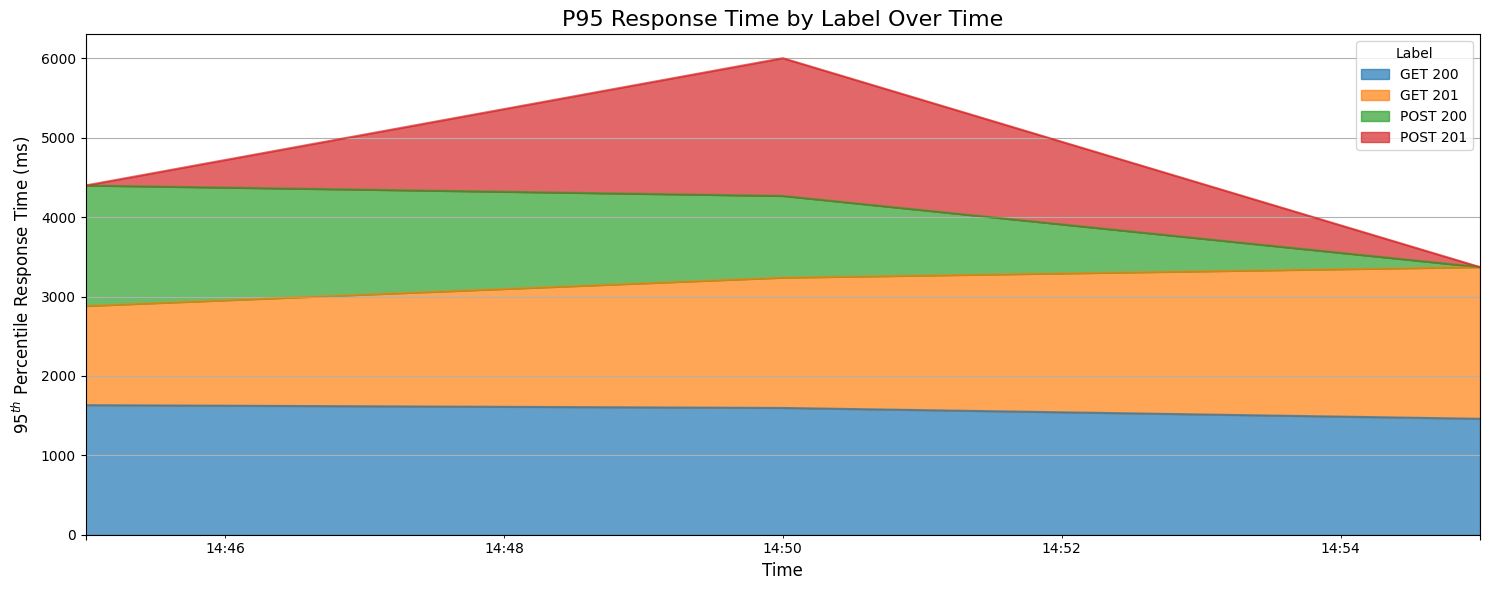

In [ ]:
from utils import plot_line_graph, plot_stacked_area_graph

# Plot the line graph
plot_line_graph(metrics_data_agg)

# Plot the stacked area graph
plot_stacked_area_graph(metrics_data_agg)

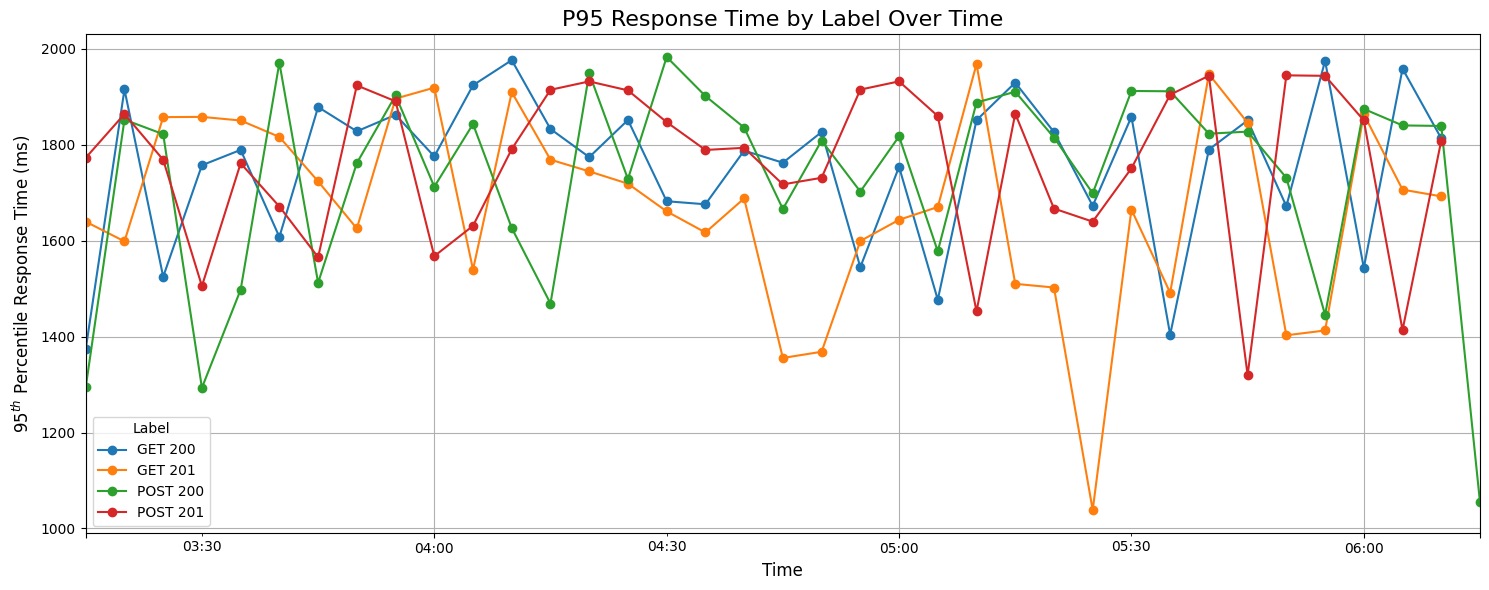

In [26]:
from utils import plot_line_graph, plot_stacked_area_graph

# Plot the line graph
plot_line_graph(metrics_data_agg)

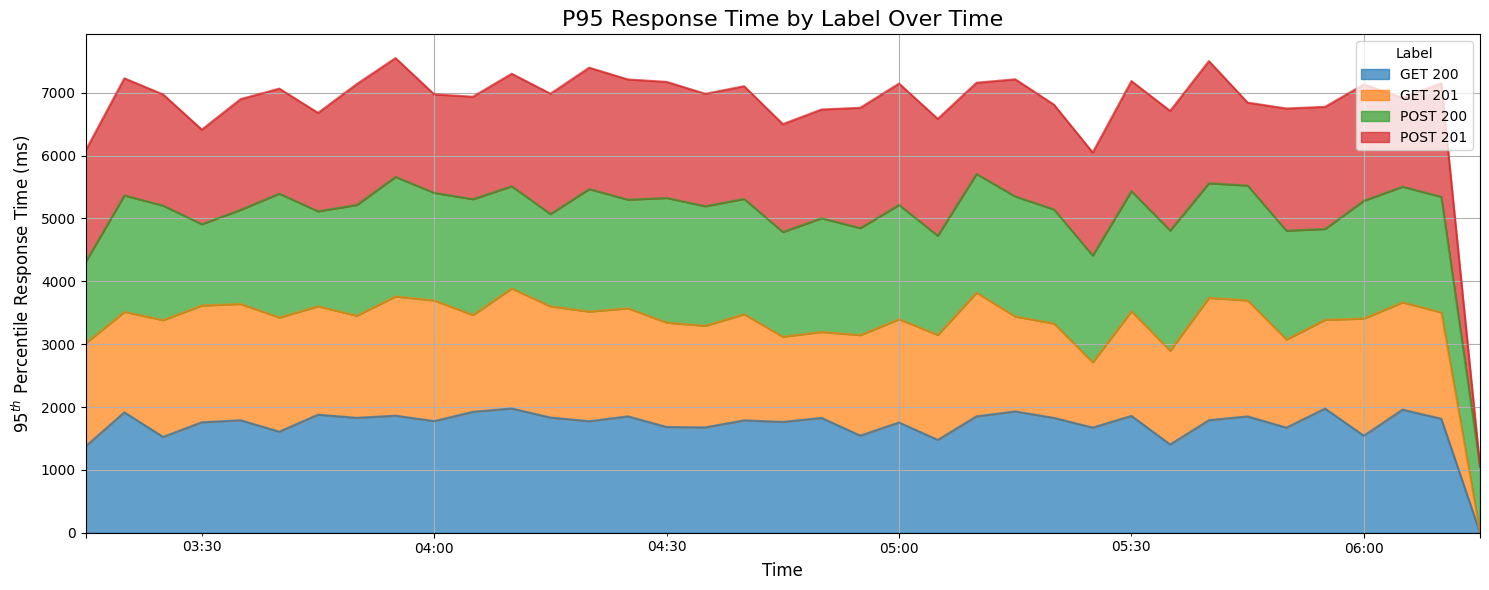

In [27]:
# Plot the stacked area graph
plot_stacked_area_graph(metrics_data_agg)

## Using [`aws-embedded-metrics`](https://github.com/awslabs/aws-embedded-metrics-python/tree/master) SDK


- [`put_metric(key: str, value: float, unit: str = "None", storage_resolution: int = 60)`](https://github.com/awslabs/aws-embedded-metrics-python/tree/master?tab=readme-ov-file#metricslogger)
  - Adds a new metric to the current logger context. 
  - Multiple metrics using the same key will be appended to an array of values. Multiple metrics cannot have same key and different storage resolution. 
  - The Embedded Metric Format supports a maximum of 100 values per key.

- `set_dimensions(*dimensions: Dict[str, str], use_default: bool = False)`
  - Explicitly override all dimensions. By default, this will disable the default dimensions, but can be configured using the keyword-only parameter `use_default`.

- `set_namespace(value: str)`
  - Sets the CloudWatch namespace that extracted metrics should be published to.